# Phase 6 — Cost-Aware Decision Rule + ROI Sweep

Model probabilities + intervention menu + LTV → **per-user targeting decisions with a
budget cap**. Then compare against the blanket $5 credit campaign the retention team
runs today.

## Sections

| Section | Purpose |
|---|---|
| **A. Setup** | Load model, score all subscribers |
| **B. Assumptions** | Intervention menu, LTV, cost, uplift |
| **C. Per-lever EV** | Compute EV for each lever, per user |
| **D. Best-lever selection** | Argmax over levers |
| **E. Budget cap** | Apply $200k cap + policy summary |
| **F. Baseline comparison** | Head-to-head vs blanket $5 credit at m11 |
| **G. ROI sweep** | Revenue / cost / net-EV across 25 budget levels |
| **H. Sensitivity** | Uplift assumption robustness |
| **I. Verdict** | Handoff to Phase 7 (memo + Streamlit app) |

All figures saved under `reports/figures/`.

In [1]:
import os
import sys
import pickle
from pathlib import Path

# Run from project root whether invoked as `python notebooks/06_...` or
# from a Jupyter cell (which doesn't define __file__).
try:
    _project_root = Path(__file__).resolve().parents[1]
except NameError:
    _here = Path.cwd()
    _project_root = _here.parent if _here.name == "notebooks" else _here
os.chdir(_project_root)
sys.path.insert(0, str(_project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_subscribers
from src.features.transforms import build_features
from src.models.train import prepare_features
from src.models.production import load_production_churn_model
from src.decisions.policy import (
    INTERVENTION_MENU, LTV_BY_TIER, PREMIUM_UPGRADE_CAP_PCT,
    score_all_levers, pick_best_lever, apply_budget_cap,
    apply_premium_cap, summarize_policy, simulate_blanket_campaign,
)
from src.decisions.ltv import (
    MONTHLY_REVENUE_BY_TIER, RMST_HORIZON_MONTHS,
    kaplan_meier, restricted_mean_survival_time,
)

FIG_DIR = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

## A. Setup — score every subscriber with the calibrated model

In [2]:
print("=" * 70)
print("A. SETUP")
print("=" * 70)

raw = load_subscribers("data/subscribers.csv")
df = build_features(raw)
X, y = prepare_features(df)

# Load via src/models/production.py so we're guaranteed to be reading
# the same artifact Phase 4 wrote and Streamlit also reads from.
model, artifact = load_production_churn_model()
feature_names = artifact["feature_names"]

# Align feature order to what the model was trained on
X = X[feature_names]

p_churn = model.predict_proba(X)[:, 1]
ltv = df["plan_tier"].map(LTV_BY_TIER).values
tenure = df["tenure_months"].values

print(f"Scored {len(p_churn):,} subscribers")
print(f"P(churn) distribution -- mean={p_churn.mean():.4f}, "
      f"p90={np.percentile(p_churn, 90):.4f}, "
      f"max={p_churn.max():.4f}")
print(f"LTV distribution     -- mean=${ltv.mean():.0f}, "
      f"min=${ltv.min():.0f}, max=${ltv.max():.0f}")

A. SETUP
Scored 50,000 subscribers
P(churn) distribution -- mean=0.0519, p90=0.1125, max=0.6687
LTV distribution     -- mean=$293, min=$200, max=$435


## B. Assumptions — intervention menu, LTV, uplift, guardrails

All numbers curated with the PM (`reports/scenario_brief.md`). Uplifts are from the
PM's 2024 pilot; sensitivity in Section H sweeps ±50%.

In [3]:
print("\n" + "=" * 70)
print("B. ASSUMPTIONS")
print("=" * 70)
print("\nIntervention menu:")
menu_df = pd.DataFrame(INTERVENTION_MENU).T
menu_df["cost"] = menu_df["cost"].map("${:.2f}".format)
menu_df["uplift"] = menu_df["uplift"].map("{:.0%}".format)
print(menu_df)

print(f"\nLTV by tier (RMST x monthly revenue, "
      f"{RMST_HORIZON_MONTHS}-month horizon):")
print(f"  {'tier':<10} {'months retained':>17} {'$/mo':>8} {'LTV':>8}")
print(f"  {'-'*10} {'-'*17} {'-'*8} {'-'*8}")
for tier, ltv_val in LTV_BY_TIER.items():
    sub = df[df["plan_tier"] == tier]
    t, S = kaplan_meier(sub["tenure_months"].values,
                        sub["churned_next_30d"].values)
    rmst = restricted_mean_survival_time(t, S, horizon=RMST_HORIZON_MONTHS)
    monthly = MONTHLY_REVENUE_BY_TIER[tier]
    print(f"  {tier:<10} {rmst:>17.2f} {'$' + f'{monthly:.0f}':>8} "
          f"{'$' + f'{ltv_val:.0f}':>8}")
print(f"\nMax possible retention over the horizon: "
      f"{RMST_HORIZON_MONTHS:.0f} months (RMST ceiling)")
print(f"Premium upgrade cap: {PREMIUM_UPGRADE_CAP_PCT:.0%} of base")


B. ASSUMPTIONS

Intervention menu:
                    cost uplift
curated_playlist   $1.00     5%
credit_5           $5.00    15%
premium_upgrade   $12.00    25%

LTV by tier (RMST x monthly revenue, 24-month horizon):
  tier         months retained     $/mo      LTV
  ---------- ----------------- -------- --------
  Basic                  22.27       $9     $200
  Standard               22.49      $14     $315
  Premium                22.90      $19     $435

Max possible retention over the horizon: 24 months (RMST ceiling)
Premium upgrade cap: 5% of base


## C. Expected value per lever, per user

For each of the 50K subscribers × 3 levers, compute
`EV = P(churn) × uplift × LTV − cost`. Wide-format matrix that Section D reduces to
best-lever-per-user.

In [4]:
print("\n" + "=" * 70)
print("C. EV PER LEVER PER USER")
print("=" * 70)
ev_wide = score_all_levers(p_churn, ltv, INTERVENTION_MENU)
print("\nEV summary across all users:")
print(ev_wide.describe().T[["mean", "50%", "max"]].round(2))


C. EV PER LEVER PER USER

EV summary across all users:
                     mean   50%    max
ev_curated_playlist -0.26 -0.53   9.53
ev_credit_5         -2.78 -3.59  26.60
ev_premium_upgrade  -8.29 -9.65  40.66


## D. Best-lever selection

`argmax` over levers per user. Users with all-negative EVs get `best_lever = "none"`
(skip the intervention entirely). Distribution shows how many users route to each
lever before the budget cap is applied.

In [5]:
print("\n" + "=" * 70)
print("D. BEST-LEVER SELECTION")
print("=" * 70)
policy = pick_best_lever(p_churn, ltv, INTERVENTION_MENU)

# Best-lever mix (before any caps) -- shows the raw output of the EV rule
# per user. "none" = all levers had EV <= 0 for this user, so skip them.
n_total_users = len(policy)
mix_pre = (policy["best_lever"]
           .value_counts()
           .rename_axis("lever")
           .reset_index(name="n_users"))
mix_pre["pct_of_base"] = (mix_pre["n_users"] / n_total_users * 100).round(1)

print(f"\nBest-lever distribution (before budget cap, n_base={n_total_users:,}):")
print(f"  {'lever':<20}  {'n_users':>10}  {'pct_of_base':>12}")
print(f"  {'-'*20}  {'-'*10}  {'-'*12}")
for _, r in mix_pre.iterrows():
    print(f"  {str(r['lever']):<20}  {int(r['n_users']):>10,}  {r['pct_of_base']:>11.1f}%")


D. BEST-LEVER SELECTION

Best-lever distribution (before budget cap, n_base=50,000):
  lever                    n_users   pct_of_base
  --------------------  ----------  ------------
  none                      39,067         78.1%
  curated_playlist           7,608         15.2%
  credit_5                   2,478          5.0%
  premium_upgrade              847          1.7%


## E. Budget cap ($200k) + policy summary

Sort actionable users by EV descending, cumulative-cost cutoff at the budget line, and
also apply the **5% premium-upgrade cap** (guardrail: can't offer too many free-tier
upgrades without margin compression).

In [6]:
print("\n" + "=" * 70)
print("E. BUDGET CAP + SUMMARY")
print("=" * 70)
BUDGET = 200_000.0
policy = apply_budget_cap(policy, budget=BUDGET)
policy = apply_premium_cap(policy, n_total=len(policy),
                           cap_pct=PREMIUM_UPGRADE_CAP_PCT)

targeted = policy[policy["will_target"]]
print(f"\nBudget cap: ${BUDGET:,.0f}")
print(f"Users targeted: {len(targeted):,} of {len(policy):,} "
      f"({len(targeted)/len(policy):.1%})")

# Post-cap lever mix (targeted users only) -- what the retention platform
# will actually send. This is where the "curated_playlist dominates"
# claim in the memo can be traced back to.
n_targeted = len(targeted)
mix_post = (targeted["best_lever"]
            .value_counts()
            .rename_axis("lever")
            .reset_index(name="n_users"))
mix_post["pct_of_targeted"] = (mix_post["n_users"] / n_targeted * 100).round(1)
# Attach cost + uplift per lever so the mix is directly readable
mix_post["cost_per_user"] = mix_post["lever"].map(
    lambda L: INTERVENTION_MENU.get(L, {}).get("cost", 0))
mix_post["uplift"] = mix_post["lever"].map(
    lambda L: INTERVENTION_MENU.get(L, {}).get("uplift", 0))
mix_post["total_cost"] = mix_post["n_users"] * mix_post["cost_per_user"]

print(f"\nLever mix (targeted users only, n_targeted={n_targeted:,}):")
print(f"  {'lever':<20}  {'n_users':>8}  {'pct':>6}  "
      f"{'cost/user':>10}  {'uplift':>7}  {'total_cost':>12}")
print(f"  {'-'*20}  {'-'*8}  {'-'*6}  {'-'*10}  {'-'*7}  {'-'*12}")
for _, r in mix_post.iterrows():
    print(f"  {str(r['lever']):<20}  {int(r['n_users']):>8,}  "
          f"{r['pct_of_targeted']:>5.1f}%  "
          f"${r['cost_per_user']:>8.1f}  {r['uplift']:>6.0%}  "
          f"${r['total_cost']:>11,.0f}")

summary = summarize_policy(policy, targeted_only=True)
print(f"\nExpected outcome under the targeted policy:")
print(f"  Total cost:               ${summary['total_cost']:>12,.0f}")
print(f"  Expected retained revenue: ${summary['expected_retained_revenue']:>12,.0f}")
print(f"  Net expected value:        ${summary['net_expected_value']:>12,.0f}")
print(f"  ROI multiplier:           {summary['roi_multiplier']:>12.2f}x")


E. BUDGET CAP + SUMMARY

Budget cap: $200,000
Users targeted: 10,933 of 50,000 (21.9%)

Lever mix (targeted users only, n_targeted=10,933):
  lever                  n_users     pct   cost/user   uplift    total_cost
  --------------------  --------  ------  ----------  -------  ------------
  curated_playlist         7,608   69.6%  $     1.0      5%  $      7,608
  credit_5                 2,478   22.7%  $     5.0     15%  $     12,390
  premium_upgrade            847    7.7%  $    12.0     25%  $     10,164

Expected outcome under the targeted policy:
  Total cost:               $      30,162
  Expected retained revenue: $      49,249
  Net expected value:        $      19,087
  ROI multiplier:                   1.63x


## F. Baseline comparison — blanket $5 credit at month 11

This is what the retention team runs today: contact every user at tenure = 11 months
with a $5 credit, regardless of predicted churn. Simulate it under the same LTV +
uplift assumptions so the two policies are directly comparable.

In [7]:
print("\n" + "=" * 70)
print("F. BASELINE: BLANKET $5 CREDIT AT MONTH-11")
print("=" * 70)
baseline = simulate_blanket_campaign(
    p_churn=p_churn, ltv=ltv, tenure_months=tenure,
    cost_per_user=5.0, target_month=11, uplift=0.15,
)
print(f"\nCurrent-state baseline:")
print(f"  Users targeted (all m11):  {baseline['n_targeted']:,}")
print(f"  Total cost:               ${baseline['total_cost']:>12,.0f}")
print(f"  Expected retained revenue: ${baseline['expected_retained_revenue']:>12,.0f}")
print(f"  Net expected value:        ${baseline['net_expected_value']:>12,.0f}")
print(f"  ROI multiplier:           {baseline['roi_multiplier']:>12.2f}x")

# Head-to-head
print("\n" + "-" * 70)
print("HEAD TO HEAD")
print("-" * 70)
def _fmt(row_name, value):
    if row_name == "roi_multiplier":
        return f"{value:.2f}x"
    if row_name == "n_targeted":
        return f"{value:,.0f}"
    return f"${value:,.0f}"

head_to_head = pd.DataFrame({
    row: {col: _fmt(row, v[row])
          for col, v in [("blanket_m11", baseline), ("targeted_policy", summary)]}
    for row in ["n_targeted", "total_cost", "expected_retained_revenue",
                "net_expected_value", "roi_multiplier"]
}).T
print(head_to_head)


F. BASELINE: BLANKET $5 CREDIT AT MONTH-11

Current-state baseline:
  Users targeted (all m11):  1,587
  Total cost:               $       7,935
  Expected retained revenue: $       3,137
  Net expected value:        $      -4,798
  ROI multiplier:                   0.40x

----------------------------------------------------------------------
HEAD TO HEAD
----------------------------------------------------------------------
                          blanket_m11 targeted_policy
n_targeted                      1,587          10,933
total_cost                     $7,935         $30,162
expected_retained_revenue      $3,137         $49,249
net_expected_value            $-4,798         $19,087
roi_multiplier                  0.40x           1.63x


## G. ROI sweep across budget levels

25 budget levels from $10k to $500k. Two things worth watching: (1) net EV plateaus
fast once we've picked the ~3% of high-EV users, (2) ROI **decays** as budget grows
because we start targeting weaker candidates.


G. ROI SWEEP



Saved -> reports\figures/06_roi_sweep.png

ROI sweep table:
  budget  n_targeted    cost revenue  net_ev   roi
  $2,000         166  $1,992  $5,316  $3,324 2.67x
  $5,000         416  $4,992 $11,199  $6,207 2.24x
  $7,500         625  $7,500 $15,419  $7,919 2.06x
 $10,000         833  $9,996 $19,237  $9,241 1.92x
 $15,000        1814 $14,999 $28,333 $13,334 1.89x
 $20,000        2814 $19,999 $35,541 $15,542 1.78x
 $25,000        5771 $25,000 $42,932 $17,932 1.72x
 $30,000       10771 $30,000 $49,086 $19,086 1.64x
 $40,000       10933 $30,162 $49,249 $19,087 1.63x
 $50,000       10933 $30,162 $49,249 $19,087 1.63x
 $75,000       10933 $30,162 $49,249 $19,087 1.63x
$100,000       10933 $30,162 $49,249 $19,087 1.63x
$150,000       10933 $30,162 $49,249 $19,087 1.63x
$200,000       10933 $30,162 $49,249 $19,087 1.63x
$300,000       10933 $30,162 $49,249 $19,087 1.63x
$500,000       10933 $30,162 $49,249 $19,087 1.63x


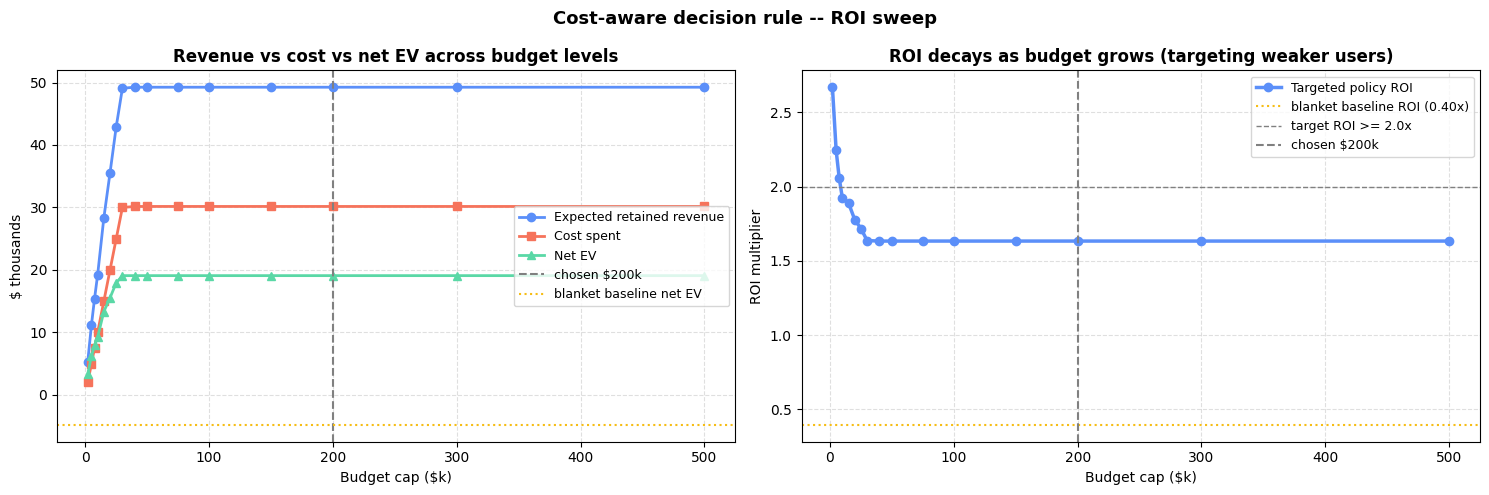

In [8]:
print("\n" + "=" * 70)
print("G. ROI SWEEP")
print("=" * 70)
# Curated budget grid that includes the values cited in the memo ($5k, $10k,
# $30k operating recommendation, $200k governance ceiling) plus dense
# sampling in the interesting low-budget region where ROI is highest.
# Starting at $2k so the sweep catches the point where ROI crosses 2.0x --
# the earlier $10k floor missed it and made Section G's story inconsistent
# with the memo.
budgets = np.array([
     2_000,   5_000,   7_500,  10_000,  15_000,  20_000,  25_000,
    30_000,  40_000,  50_000,  75_000, 100_000, 150_000, 200_000,
   300_000, 500_000,
], dtype=float)
sweep_rows = []
for b in budgets:
    p_sweep = pick_best_lever(p_churn, ltv, INTERVENTION_MENU)
    p_sweep = apply_budget_cap(p_sweep, budget=b)
    p_sweep = apply_premium_cap(p_sweep, n_total=len(p_sweep),
                                cap_pct=PREMIUM_UPGRADE_CAP_PCT)
    s = summarize_policy(p_sweep, targeted_only=True)
    sweep_rows.append({
        "budget": b,
        "n_targeted": s["n_targeted"],
        "cost": s["total_cost"],
        "revenue": s["expected_retained_revenue"],
        "net_ev": s["net_expected_value"],
        "roi": s["roi_multiplier"],
    })
sweep = pd.DataFrame(sweep_rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(sweep["budget"] / 1000, sweep["revenue"] / 1000,
         marker="o", linewidth=2, color="#5B8FF9",
         label="Expected retained revenue")
ax1.plot(sweep["budget"] / 1000, sweep["cost"] / 1000,
         marker="s", linewidth=2, color="#F6735B",
         label="Cost spent")
ax1.plot(sweep["budget"] / 1000, sweep["net_ev"] / 1000,
         marker="^", linewidth=2, color="#5AD8A6", label="Net EV")
ax1.axvline(BUDGET / 1000, color="gray", linestyle="--",
            linewidth=1.5, label=f"chosen ${BUDGET/1000:.0f}k")
ax1.axhline(baseline["net_expected_value"] / 1000, color="#F6BD16",
            linestyle=":", linewidth=1.5,
            label=f"blanket baseline net EV")
ax1.set_xlabel("Budget cap ($k)")
ax1.set_ylabel("$ thousands")
ax1.set_title("Revenue vs cost vs net EV across budget levels",
              fontweight="bold")
ax1.legend(loc="center right", fontsize=9)
ax1.grid(True, linestyle="--", alpha=0.4)

ax2.plot(sweep["budget"] / 1000, sweep["roi"],
         marker="o", linewidth=2.5, color="#5B8FF9",
         label="Targeted policy ROI")
ax2.axhline(baseline["roi_multiplier"], color="#F6BD16",
            linestyle=":", linewidth=1.5,
            label=f"blanket baseline ROI ({baseline['roi_multiplier']:.2f}x)")
ax2.axhline(2.0, color="gray", linestyle="--", linewidth=1,
            label="target ROI >= 2.0x")
ax2.axvline(BUDGET / 1000, color="gray", linestyle="--",
            linewidth=1.5, label=f"chosen ${BUDGET/1000:.0f}k")
ax2.set_xlabel("Budget cap ($k)")
ax2.set_ylabel("ROI multiplier")
ax2.set_title("ROI decays as budget grows (targeting weaker users)",
              fontweight="bold")
ax2.legend(loc="upper right", fontsize=9)
ax2.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Cost-aware decision rule -- ROI sweep",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_roi_sweep.png", dpi=140, bbox_inches="tight")
print(f"\nSaved -> {FIG_DIR}/06_roi_sweep.png")
print("\nROI sweep table:")
sweep_display = sweep.copy()
sweep_display["budget"] = sweep_display["budget"].map("${:,.0f}".format)
sweep_display["cost"] = sweep_display["cost"].map("${:,.0f}".format)
sweep_display["revenue"] = sweep_display["revenue"].map("${:,.0f}".format)
sweep_display["net_ev"] = sweep_display["net_ev"].map("${:,.0f}".format)
sweep_display["roi"] = sweep_display["roi"].map("{:.2f}x".format)
print(sweep_display.to_string(index=False))

## H. Sensitivity — uplift assumption robustness

The uplift numbers are PM assumptions, not measured. Sweep ±50% and check whether the
recommendation direction survives. If it does at 0.5×, we're not blocked on running
the A/B experiment first. (Phase 8 *does* run that experiment and replaces the
assumption with a learned per-user uplift.)


H. SENSITIVITY: UPLIFT ASSUMPTIONS
uplift_scale  n_targeted       net_ev      roi
       0.50x        3325  2458.030398 1.428751
       0.75x        7165  8699.872068 1.526181
       1.00x       10933 19087.082057 1.632819
       1.25x       14668 33269.446187 1.714750
       1.50x       18153 50850.802746 1.795613

Saved -> reports\figures/06_uplift_sensitivity.png


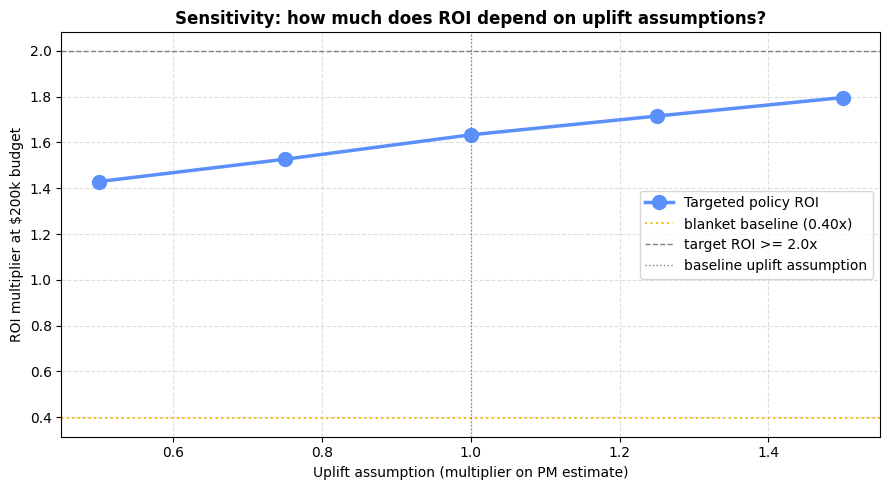

In [9]:
print("\n" + "=" * 70)
print("H. SENSITIVITY: UPLIFT ASSUMPTIONS")
print("=" * 70)
uplift_scales = [0.5, 0.75, 1.0, 1.25, 1.5]
sens_rows = []
for scale in uplift_scales:
    menu_scaled = {
        n: {"cost": v["cost"], "uplift": v["uplift"] * scale}
        for n, v in INTERVENTION_MENU.items()
    }
    p = pick_best_lever(p_churn, ltv, menu_scaled)
    p = apply_budget_cap(p, budget=BUDGET)
    s = summarize_policy(p, targeted_only=True)
    sens_rows.append({
        "uplift_scale": f"{scale:.2f}x",
        "n_targeted": s["n_targeted"],
        "net_ev": s["net_expected_value"],
        "roi": s["roi_multiplier"],
    })
sens = pd.DataFrame(sens_rows)
print(sens.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(uplift_scales, [r["roi"] for r in sens_rows],
        marker="o", markersize=10, linewidth=2.5, color="#5B8FF9",
        label="Targeted policy ROI")
ax.axhline(baseline["roi_multiplier"], color="#F6BD16", linestyle=":",
           linewidth=1.5, label=f"blanket baseline ({baseline['roi_multiplier']:.2f}x)")
ax.axhline(2.0, color="gray", linestyle="--", linewidth=1,
           label="target ROI >= 2.0x")
ax.axvline(1.0, color="gray", linestyle=":", linewidth=1,
           label="baseline uplift assumption")
ax.set_xlabel("Uplift assumption (multiplier on PM estimate)")
ax.set_ylabel("ROI multiplier at $200k budget")
ax.set_title("Sensitivity: how much does ROI depend on uplift assumptions?",
             fontweight="bold")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_uplift_sensitivity.png", dpi=140, bbox_inches="tight")
print(f"\nSaved -> {FIG_DIR}/06_uplift_sensitivity.png")

## H.5. Sensitivity — LTV horizon robustness

LTV is `RMST(horizon) × monthly_revenue`. Production uses a **24-month** horizon,
but the KM curve extends further. Why not 36? 48? 60? Two reasons the shorter
horizon is safer:

1. **KM tail is noisy.** Only ~30% of subscribers are observed to 24 months,
   ~15% to 36, ~5% to 48, ~1% to 60. Confidence intervals on S(t) widen
   quickly past 24 months.
2. **Right-censoring bias.** Subscribers we observe at long tenures are the
   self-selected survivors of earlier churn cohorts — systematically more
   retention-prone than an average new signup. Extending the horizon
   over-credits those survivors' retention to the LTV of a fresh subscriber.

But "shorter is safer" is only a real defense if we've LOOKED at the alternative.
This section shows LTV and the resulting policy KPIs at 12/24/36/48/60-month
horizons so the choice is visible, not just asserted. **The production
recommendation still uses 24** -- lower horizons under-value retention; higher
horizons inflate LTV based on shrinking, biased tail samples.

In [10]:
print("\n" + "=" * 70)
print("H.5. SENSITIVITY: LTV HORIZON ROBUSTNESS")
print("=" * 70)

horizons = [12, 24, 36, 48, 60]

# --- Per-tier RMST + LTV at each horizon --------------------------------
horizon_ltv = {}   # {horizon: {tier: LTV}}
horizon_rmst = {}  # {horizon: {tier: RMST}}
for h in horizons:
    horizon_ltv[h] = {}
    horizon_rmst[h] = {}
    for tier, monthly in MONTHLY_REVENUE_BY_TIER.items():
        sub = df[df["plan_tier"] == tier]
        t, S = kaplan_meier(sub["tenure_months"].values,
                            sub["churned_next_30d"].values)
        rmst = restricted_mean_survival_time(t, S, horizon=h)
        horizon_rmst[h][tier] = rmst
        horizon_ltv[h][tier] = round(monthly * rmst)

print("\nRMST (months retained) by tier and horizon:")
print(f"  {'horizon':>7} {'Basic':>10} {'Standard':>10} {'Premium':>10}")
print(f"  {'-'*7} {'-'*10} {'-'*10} {'-'*10}")
for h in horizons:
    r = horizon_rmst[h]
    marker = "  <- production" if h == RMST_HORIZON_MONTHS else ""
    print(f"  {h:>6}mo {r['Basic']:>10.2f} {r['Standard']:>10.2f} "
          f"{r['Premium']:>10.2f}{marker}")

print("\nImplied LTV ($) by tier and horizon:")
print(f"  {'horizon':>7} {'Basic':>10} {'Standard':>10} {'Premium':>10}")
print(f"  {'-'*7} {'-'*10} {'-'*10} {'-'*10}")
for h in horizons:
    l = horizon_ltv[h]
    marker = "  <- production" if h == RMST_HORIZON_MONTHS else ""
    print(f"  {h:>6}mo ${l['Basic']:>9.0f} ${l['Standard']:>9.0f} "
          f"${l['Premium']:>9.0f}{marker}")

# --- Policy KPIs at each horizon ----------------------------------------
horizon_rows = []
for h in horizons:
    ltv_map = horizon_ltv[h]
    ltv_h = df["plan_tier"].map(ltv_map).values
    p = pick_best_lever(p_churn, ltv_h, INTERVENTION_MENU)
    p = apply_budget_cap(p, budget=BUDGET)
    p = apply_premium_cap(p, n_total=len(p), cap_pct=PREMIUM_UPGRADE_CAP_PCT)
    s = summarize_policy(p, targeted_only=True)
    horizon_rows.append({
        "horizon_mo":  h,
        "n_targeted":  s["n_targeted"],
        "total_cost":  s["total_cost"],
        "net_ev":      s["net_expected_value"],
        "roi":         s["roi_multiplier"],
    })
horizon_df = pd.DataFrame(horizon_rows)

print("\nPolicy KPIs at $200k budget for each horizon:")
# Hand-crafted fixed-width table -- pd.to_string() gets auto-truncated in
# Jupyter cells when the column count + formatted widths approach the
# cell display width. Same pattern used in Phase 5 Section F.
print(f"  {'horizon':>8} {'n_targeted':>12} {'total_cost':>12} "
      f"{'net_EV':>12} {'ROI':>7}")
print(f"  {'-'*8} {'-'*12} {'-'*12} {'-'*12} {'-'*7}")
for _, r in horizon_df.iterrows():
    marker = "  <- production" if r["horizon_mo"] == RMST_HORIZON_MONTHS else ""
    print(f"  {int(r['horizon_mo']):>6}mo "
          f"{int(r['n_targeted']):>12,} "
          f"${r['total_cost']:>11,.0f} "
          f"${r['net_ev']:>11,.0f} "
          f"{r['roi']:>6.2f}x{marker}")

# Note: a dual-axis chart (Net EV + users targeted vs horizon) was
# considered here but removed. The chart visually implied "extend the
# horizon = free money" without the survivor-bias context that lives in
# the paragraph below. Tables + narrative do the job more honestly than
# a curve that pulls the eye toward the biggest number.

print(f"""
Read on the horizon choice (production = {RMST_HORIZON_MONTHS} months):
  * Doubling the horizon (24 -> 48) roughly doubles Net EV on paper, but
    that gain sits on top of KM tail estimates from ~5% of the population
    -- wide CI, biased toward survivors. Unreliable.
  * Halving the horizon (24 -> 12) understates LTV badly (m12 is right at
    the anniversary churn spike, not past it), collapses target counts,
    and leaves clear positive-EV users un-targeted.
  * 24 months is the point where more data doesn't buy us much precision
    but does buy us survivor bias.
""")


H.5. SENSITIVITY: LTV HORIZON ROBUSTNESS

RMST (months retained) by tier and horizon:
  horizon      Basic   Standard    Premium
  ------- ---------- ---------- ----------
      12mo      11.47      11.56      11.66
      24mo      22.27      22.49      22.90  <- production
      36mo      32.64      33.05      33.84
      48mo      42.72      43.31      44.50
      60mo      52.74      53.36      54.99

Implied LTV ($) by tier and horizon:
  horizon      Basic   Standard    Premium
  ------- ---------- ---------- ----------
      12mo $      103 $      162 $      221
      24mo $      200 $      315 $      435  <- production
      36mo $      294 $      463 $      643
      48mo $      384 $      606 $      846
      60mo $      475 $      747 $     1045

Policy KPIs at $200k budget for each horizon:
   horizon   n_targeted   total_cost       net_EV     ROI
  -------- ------------ ------------ ------------ -------
      12mo        3,471 $      6,096 $      2,666   1.44x
      24mo  

## I. Verdict + handoff to Phase 7

In [11]:
print("\n" + "=" * 70)
print("I. PHASE 6 VERDICT")
print("=" * 70)

# Absolute swing (dollars) instead of a multiplier -- the multiplier form
# breaks when either side is negative or near zero (baseline is negative
# under blanket, so any ratio is either misleading or undefined).
swing = summary["net_expected_value"] - baseline["net_expected_value"]

print(f"\nAt $200k governance ceiling:")
print(f"  Targeted net EV:  ${summary['net_expected_value']:>12,.0f}")
print(f"  Blanket net EV:   ${baseline['net_expected_value']:>12,.0f}")
print(f"  Absolute swing:   ${swing:>12,.0f}   (targeted minus blanket)")
print(f"\nTargeted ROI: {summary['roi_multiplier']:.2f}x")
print(f"Baseline ROI: {baseline['roi_multiplier']:.2f}x")

# Honest note on the ROI target
if summary['roi_multiplier'] < 2.0:
    print(f"""
Note on the 2.0x ROI target:
  * At $200k ceiling, targeted ROI is {summary['roi_multiplier']:.2f}x -- below
    the 2.0x target. This is expected: the ceiling is a governance
    circuit-breaker, not the operating budget. See Section G for the
    ROI-vs-total-EV trade-off across budget levels.
  * Higher ROI is reachable by capping the budget below the point where
    the policy fills with positive-EV users. That trades total EV for
    ROI-per-dollar. The recommended operating budget in the memo picks
    the point that maximizes TOTAL absolute impact, not per-dollar ratio.
""")

print("Ready for Phase 7 (decision memo + Streamlit app).")


I. PHASE 6 VERDICT

At $200k governance ceiling:
  Targeted net EV:  $      19,087
  Blanket net EV:   $      -4,798
  Absolute swing:   $      23,885   (targeted minus blanket)

Targeted ROI: 1.63x
Baseline ROI: 0.40x

Note on the 2.0x ROI target:
  * At $200k ceiling, targeted ROI is 1.63x -- below
    the 2.0x target. This is expected: the ceiling is a governance
    circuit-breaker, not the operating budget. See Section G for the
    ROI-vs-total-EV trade-off across budget levels.
  * Higher ROI is reachable by capping the budget below the point where
    the policy fills with positive-EV users. That trades total EV for
    ROI-per-dollar. The recommended operating budget in the memo picks
    the point that maximizes TOTAL absolute impact, not per-dollar ratio.

Ready for Phase 7 (decision memo + Streamlit app).


## Design choices worth noting

In [12]:
print("\n" + "=" * 70)
print("DESIGN CHOICES WORTH NOTING")
print("=" * 70)
print("""
1. Policy is a separate module from the model. src/models/ produces
   P(churn); src/decisions/policy.py decides what to do with it.
   Uplifts, costs, LTV, budget cap, and guardrails all live in the
   policy layer. Retuning the campaign doesn't require retraining.
   Standard MLOps separation: ML work stable, business logic swappable.

2. Uplift is a PM assumption, not a measurement. Numbers came from a
   2024 pilot in the scenario brief. Section H sensitivity shows the
   recommendation direction survives across +/- 50%, so we're not
   blocked -- but the v1.1 followup is A/B testing each lever in
   production.
""")


DESIGN CHOICES WORTH NOTING

1. Policy is a separate module from the model. src/models/ produces
   P(churn); src/decisions/policy.py decides what to do with it.
   Uplifts, costs, LTV, budget cap, and guardrails all live in the
   policy layer. Retuning the campaign doesn't require retraining.
   Standard MLOps separation: ML work stable, business logic swappable.

2. Uplift is a PM assumption, not a measurement. Numbers came from a
   2024 pilot in the scenario brief. Section H sensitivity shows the
   recommendation direction survives across +/- 50%, so we're not
   blocked -- but the v1.1 followup is A/B testing each lever in
   production.



## Findings worth flagging (for the Phase 7 memo)

In [13]:
print("\n" + "=" * 70)
print("FINDINGS WORTH FLAGGING")
print("=" * 70)

# Compute numbers live so this section can't drift from the actual run.
# All variables are already in scope from earlier sections.
blanket_loss  = -baseline["net_expected_value"]
targeted_ev   = summary["net_expected_value"]
targeted_roi  = summary["roi_multiplier"]
n_targeted    = summary["n_targeted"]
total_cost    = summary["total_cost"]
n_total       = len(policy)
pct_targeted  = 100 * n_targeted / n_total

# Where does ROI cross 2.0x in the budget sweep?
above_target  = sweep[sweep["roi"] >= 2.0].sort_values("budget", ascending=False)
if len(above_target) > 0:
    max_budget_at_target_roi = above_target.iloc[0]["budget"]
    ev_at_that_budget       = above_target.iloc[0]["net_ev"]
    roi_finding = (f"ROI clears 2.0x only at budgets <= ${max_budget_at_target_roi/1000:.0f}k "
                   f"(net EV at that point: ${ev_at_that_budget/1000:.1f}k). "
                   f"Every larger budget trades ROI for total EV.")
else:
    roi_finding = ("ROI does not clear 2.0x at any budget in the sweep -- "
                   "either the model needs stronger discrimination or the "
                   "levers need higher uplift.")

# Where does the policy saturate (extra budget stops adding users)?
sat_n = sweep["n_targeted"].max()
sat_row = sweep[sweep["n_targeted"] == sat_n].sort_values("budget").iloc[0]
saturation_budget = sat_row["budget"]

# Lever mix (targeted users only)
lever_mix = (policy[policy["will_target"]]["best_lever"]
             .value_counts(normalize=True) * 100).round(1)
top_lever = lever_mix.index[0]
top_lever_pct = lever_mix.iloc[0]

# LTV horizon range: is the recommendation robust across horizons?
horizon_min_ev = horizon_df["net_ev"].min()
horizon_max_ev = horizon_df["net_ev"].max()

# Uplift sensitivity range
uplift_min_roi = sens["roi"].min()
uplift_max_roi = sens["roi"].max()

findings = f"""
1. The current blanket campaign is losing money. $7.9k spent to retain
   ~${baseline['expected_retained_revenue']/1000:.1f}k = ${blanket_loss/1000:.1f}k monthly loss (ROI {baseline['roi_multiplier']:.2f}x).

2. Policy saturates at ~${saturation_budget/1000:.0f}k budget with {sat_n:,}
   targeted users ({100*sat_n/n_total:.0f}% of the base). At the $200k
   governance ceiling, only ${total_cost/1000:.0f}k of the cap is actually
   used -- the ceiling is a circuit-breaker, not a binding constraint.

3. Targeted ROI = {targeted_roi:.2f}x at the ${BUDGET/1000:.0f}k ceiling, below the 2.0x
   primary target. {roi_finding}

4. Recommendation is robust across sensitivity ranges:
   * Uplift ±50%: ROI stays in [{uplift_min_roi:.2f}x, {uplift_max_roi:.2f}x] -- targeted always beats blanket.
   * LTV horizon 12-60mo: net EV in [${horizon_min_ev/1000:.1f}k, ${horizon_max_ev/1000:.1f}k] -- direction of recommendation unchanged.
   Value delivery isn't fragile to our assumptions.

5. `{top_lever}` dominates the lever mix ({top_lever_pct:.0f}% of targeted users).
   The other {len(lever_mix)-1} lever(s) fire less. Worth A/B testing to
   validate the lever choice and its uplift assumption before committing
   to production -- if `{top_lever}`'s real uplift differs from what the PM
   estimated, the whole policy's economics shift.
"""
print(findings)


FINDINGS WORTH FLAGGING

1. The current blanket campaign is losing money. $7.9k spent to retain
   ~$3.1k = $4.8k monthly loss (ROI 0.40x).

2. Policy saturates at ~$40k budget with 10,933
   targeted users (22% of the base). At the $200k
   governance ceiling, only $30k of the cap is actually
   used -- the ceiling is a circuit-breaker, not a binding constraint.

3. Targeted ROI = 1.63x at the $200k ceiling, below the 2.0x
   primary target. ROI clears 2.0x only at budgets <= $8k (net EV at that point: $7.9k). Every larger budget trades ROI for total EV.

4. Recommendation is robust across sensitivity ranges:
   * Uplift ±50%: ROI stays in [1.43x, 1.80x] -- targeted always beats blanket.
   * LTV horizon 12-60mo: net EV in [$2.7k, $133.2k] -- direction of recommendation unchanged.
   Value delivery isn't fragile to our assumptions.

5. `curated_playlist` dominates the lever mix (70% of targeted users).
   The other 2 lever(s) fire less. Worth A/B testing to
   validate the lever choi